In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("TS_PDP_0032_20250604.csv");
print(df.head())

                                             dailyid  year  month  day  \
0  9e992268b348cc9b7e5721de42cfa76b934d17ad40cba6...  2025      6    4   
1  0da6f19b79b935a1f0a2b1dee30196faacb452cbb587d5...  2025      6    4   
2  17abfca381151c06b3da04078c376d667863ae253f3e72...  2025      6    4   
3  0da6f19b79b935a1f0a2b1dee30196faacb452cbb587d5...  2025      6    4   
4  17abfca381151c06b3da04078c376d667863ae253f3e72...  2025      6    4   

   dayofweek  hour  minute   latitude   longitude   os  ... citycode  \
0          3     0       0  42.670167  141.671071  iOS  ...   1213.0   
1          3     0       0  35.608466  140.152198  iOS  ...  12104.0   
2          3     0       0  42.790710  141.676219  iOS  ...   1224.0   
3          3     0       0  35.608261  140.152840  iOS  ...  12104.0   
4          3     0       0  42.792053  141.673097  iOS  ...   1224.0   

   mesh100mid home_prefcode  home_citycode  workplace_prefcode  \
0  6441050346             1           1213              

In [14]:
df.isnull().sum()

,0
dailyid,0
year,0
month,0
day,0
dayofweek,0
hour,0
minute,0
latitude,0
longitude,0
os,188


In [15]:
df.describe()

,year,month,day,dayofweek,hour,minute,latitude,longitude,accuracy,speed,...,course,estimated_course_flag,prefcode,citycode,mesh100mid,home_prefcode,home_citycode,workplace_prefcode,workplace_citycode,estimated_logic_flag
count,916206.0,916206.0,916206.0,916206.0,916206.000000,916206.000000,916206.000000,916206.000000,916206.000000,864554.000000,...,854494.000000,854494.000000,916206.000000,914160.000000,9.162060e+05,916206.000000,916206.000000,906475.000000,906475.000000,916206.0
mean,2025.0,6.0,4.0,3.0,13.038258,29.497666,41.955821,141.176830,168.890925,12.457509,...,186.135468,1.183716,3.130284,3353.401847,6.290237e+09,5.345968,5533.880242,5.370244,5560.690092,2.0
std,0.0,0.0,0.0,0.0,4.878394,17.282714,2.534137,1.671012,3604.210541,24.250425,...,103.507624,0.387252,6.609573,6581.065043,3.822656e+08,9.127169,9122.572206,9.144041,9135.875078,0.0
min,2025.0,6.0,4.0,3.0,0.000000,0.000000,24.719084,125.276500,0.000000,0.000000,...,0.000000,1.000000,1.000000,1101.000000,3.725027e+09,1.000000,1101.000000,1.000000,1101.000000,2.0
25%,2025.0,6.0,4.0,3.0,9.000000,15.000000,42.672332,141.350373,4.100000,0.970000,...,101.440000,1.000000,1.000000,1213.000000,6.440674e+09,1.000000,1109.000000,1.000000,1110.000000,2.0
50%,2025.0,6.0,4.0,3.0,13.000000,29.000000,42.842458,141.572793,6.400000,8.560000,...,179.880000,1.000000,1.000000,1224.000000,6.441244e+09,1.000000,1224.000000,1.000000,1224.000000,2.0
75%,2025.0,6.0,4.0,3.0,17.000000,44.000000,43.007049,141.672317,19.000000,16.990000,...,281.880000,1.000000,1.000000,1345.000000,6.441428e+09,1.000000,1585.000000,1.000000,1586.000000,2.0
max,2025.0,6.0,4.0,3.0,23.000000,59.000000,45.418289,145.812763,442898.000000,437.830000,...,360.000000,2.000000,47.000000,47362.000000,6.841150e+09,47.000000,47362.000000,47.000000,47362.000000,2.0


## 都市計画視点：100mメッシュによる「溜まり場」の特定

**目的**: `logtype_subcategory == arrival` に絞り、到着地点（目的地候補）ごとに滞在が長い傾向があるメッシュを可視化する。

**滞在時間の定義（本データ）**: 元データに滞在分数の列がないため、同一 `dailyid` について時刻順に並べたとき、**各 arrival レコードのタイムスタンプから、直後の全ログのタイムスタンプまでの経過時間（秒）**をその到着に対する滞在の近似とする（次のイベント＝移動・別メッシュへの記録などで「滞在終了」とみなす）。

**ヒートマップの指標**:
- メッシュ別 **滞在時間合計（人・時間の合計に近い解釈）**
- **長時間滞在**（例: 30分以上）の到着件数が多いメッシュ

地図データ（OpenStreetMap 等）と重ねると、コンビニ・公園・駅周辺などの微細なホットスポットの解釈に使える。

In [16]:
# arrival のみ・滞在時間（近似）の算出とメッシュ集計
LONG_DWELL_SEC = 30 * 60  # 「長い滞在」の閾値（秒）。レポート用に変更可

arr = df[df["logtype_subcategory"].astype(str).str.lower() == "arrival"].copy()
arr["ts"] = pd.to_datetime(arr["timestamp"])
arr = arr.sort_values(["dailyid", "ts"])
arr["next_ts"] = arr.groupby("dailyid")["ts"].shift(-1)
arr["dwell_sec"] = (arr["next_ts"] - arr["ts"]).dt.total_seconds()

# 異常値の除去：0以下、24時間超はノイズ・日跨ぎ等として除外
arr = arr.dropna(subset=["next_ts", "dwell_sec"])
arr = arr[(arr["dwell_sec"] > 0) & (arr["dwell_sec"] <= 86400)]

mesh = (
    arr.groupby("mesh100mid", as_index=False)
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        arrival_n=("mesh100mid", "count"),
        dwell_total_sec=("dwell_sec", "sum"),
        dwell_long_n=("dwell_sec", lambda s: (s >= LONG_DWELL_SEC).sum()),
    )
)
mesh["dwell_total_h"] = mesh["dwell_total_sec"] / 3600
mesh = mesh.sort_values("dwell_total_h", ascending=False)

print(f"arrival レコード数: {len(arr):,}")
print(f"メッシュ数: {len(mesh):,}")
mesh.head(15)

arrival レコード数: 1,580
メッシュ数: 912


,mesh100mid,latitude,longitude,arrival_n,dwell_total_sec,dwell_long_n,dwell_total_h
389,6441154676,42.789303,141.707835,7,151380.0,3,42.050000
374,6441154454,42.787847,141.680703,15,66420.0,7,18.450000
591,6441250963,42.838775,141.742355,9,65220.0,4,18.116667
145,5940500466,39.755323,140.058139,4,60000.0,2,16.666667
289,6441050346,42.670196,141.671149,2,54960.0,1,15.266667
604,6441251228,42.844100,141.661237,2,53520.0,1,14.866667
43,5339265297,35.549588,139.784092,9,53340.0,5,14.816667
109,5339477485,35.732465,139.932324,1,46380.0,1,12.883333
358,6441154424,42.785731,141.680425,6,45840.0,2,12.733333
472,6441159231,42.828101,141.651971,4,45540.0,2,12.650000


/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 32239 (\N{CJK UNIFIED IDEOGRAPH-7DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3563633827.py:40: UserWarning: Glyph 12517 (\N{KATAKANA LETTER SMALL YU}) missing from font(

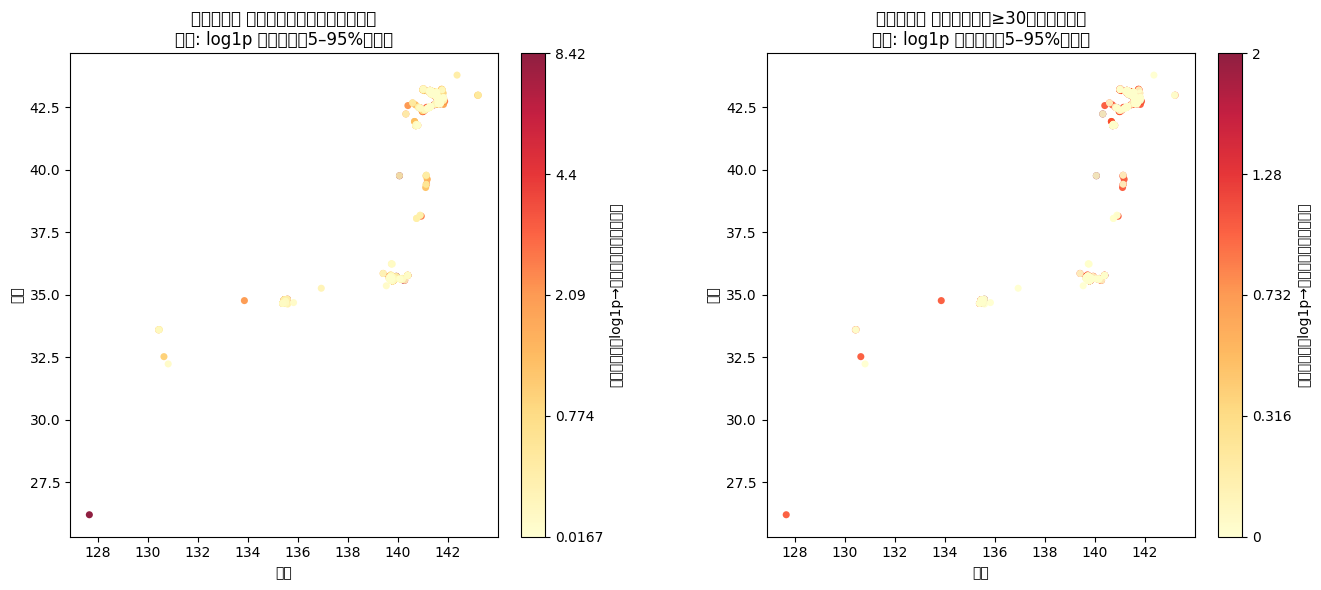

In [17]:
# ヒートマップ風散布図（メッシュ重心 × 集計値）
# 滞在合計・件数は右に偏りやすいので、色は log1p 変換 + 分位でレンジを取り、差が見えるようにする
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


def _scatter_metric(ax, mesh_df, col, title, cmap="YlOrRd", pct=(5, 95)):
    v = mesh_df[col].to_numpy(dtype=float)
    # log(1+x): 0 付近も扱え、大きい値の差を圧縮して色のばらつきが出やすい
    v_color = np.log1p(np.maximum(v, 0))
    lo, hi = np.percentile(v_color, list(pct))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        lo, hi = float(np.min(v_color)), float(np.max(v_color)) + 1e-9
    norm = Normalize(vmin=lo, vmax=hi)
    sc = ax.scatter(
        mesh_df["longitude"],
        mesh_df["latitude"],
        c=v_color,
        cmap=cmap,
        norm=norm,
        s=26,
        alpha=0.88,
        edgecolors="none",
    )
    cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    tick_pos = np.linspace(lo, hi, num=5)
    cb.set_ticks(tick_pos)
    cb.set_ticklabels([f"{np.expm1(t):.3g}" for t in tick_pos])
    cb.set_label("指標の目安（log1p→元の値に戻した表示）")
    ax.set_title(title + "\n（色: log1p スケール・%d–%d%%分位）" % (pct[0], pct[1]))
    ax.set_xlabel("経度")
    ax.set_ylabel("緯度")
    ax.set_aspect("equal", adjustable="box")


_scatter_metric(axes[0], mesh, "dwell_total_h", "メッシュ別 滞在時間合計（時間・近似）")
_scatter_metric(axes[1], mesh, "dwell_long_n", f"メッシュ別 長時間滞在（≥{LONG_DWELL_SEC//60}分）到着件数")

plt.tight_layout()
plt.show()

In [18]:
# オプション: folium が入っていれば OSM 上にヒートレイヤを重ねる
try:
    from IPython.display import display
    import folium
    from folium.plugins import HeatMap

    center_lat = float(mesh["latitude"].median())
    center_lon = float(mesh["longitude"].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="OpenStreetMap")

    # 重み: 長時間滞在件数（合計滞在時間に変えたい場合は dwell_total_h を使う）
    heat_data = mesh[["latitude", "longitude", "dwell_long_n"]].values.tolist()
    HeatMap(heat_data, radius=12, blur=18, max_zoom=13).add_to(m)
    display(m)
except ImportError:
    print("インタラクティブ地図を使う場合: pip install folium")

## マーケティング視点：ターゲット層の回遊動態分析

**目的**: `gender`・`age` と `hour`（および到着地点の `mesh100mid`）を使い、**10代・20代**と**高齢層**で「いつ・どこ」に滞在が偏るかを比較する。

**層の定義（本データの `age` 表記に合わせる）**:
- **若年（10代・20代）**: `19under`, `20-29`
- **高齢層**: `60-69`, `70over`
- 上記以外・欠損は比較から除外（必要なら下の集合を編集）。

**滞在の単位**: 都市計画セルと同様に `logtype_subcategory == arrival` の行を「到着＝滞在の起点」とし、欠損のない `age` 行のみを分析する。

**読み方**:
- **時間帯**: 正規化した出現割合（各層内で合計1）を重ねて、活動ピークのズレを見る。
- **空間**: メッシュごとに「若年の割合 − 高齢の割合」の**差分**を描き、若年寄り／シニア寄りの棲み分けを可視化する（サンプル数が少ないメッシュはノイズになりやすい）。
- **深夜帯**（任意）: `hour` が 22–23 時または 0–4 時に絞り、防犯・深夜需要の議論用に再利用できる。

In [19]:
# 到着ログ + 属性（滞在時間の欠損で落ちた行も含め、到着ベースで層比較する）
def _arrival_logs(df_):
    a = df_[df_["logtype_subcategory"].astype(str).str.lower() == "arrival"].copy()
    return a.dropna(subset=["age"])

arr_m = _arrival_logs(df)

AGE_YOUNG = {"19under", "20-29"}
AGE_SENIOR = {"60-69", "70over"}

seg = arr_m["age"].astype(str).str.strip()
mark = arr_m.assign(
    segment=np.select(
        [seg.isin(AGE_YOUNG), seg.isin(AGE_SENIOR)],
        ["young", "senior"],
        default="other",
    )
)
mark = mark[mark["segment"] != "other"].copy()

print("層別 レコード数（arrival）")
print(mark["segment"].value_counts())
print()
print("性別 × 層（参考）")
print(pd.crosstab(mark["segment"], mark["gender"], margins=True))

層別 レコード数（arrival）
segment
young     621
senior    209
Name: count, dtype: int64

性別 × 層（参考）
gender     f    m  All
segment               
senior    46  163  209
young    168  434  602
All      214  597  811


/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 21106 (\N{CJK UNIFIED IDEOGRAPH-5272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/2255444132.py:19: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missi

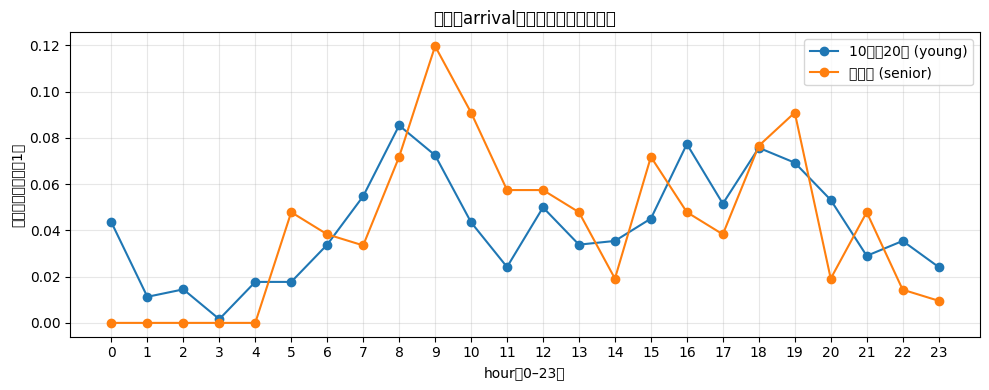

深夜帯（22–23時, 0–4時）到着の層内シェア（young / senior の比率）
segment
young     0.948454
senior    0.051546
Name: proportion, dtype: float64


In [20]:
# 時間帯（hour）: 層内で正規化した出現割合
h_y = mark[mark["segment"] == "young"].groupby("hour").size()
h_s = mark[mark["segment"] == "senior"].groupby("hour").size()
h_y = h_y / h_y.sum()
h_s = h_s / h_s.sum()
hours = np.arange(24)
p_y = h_y.reindex(hours, fill_value=0)
p_s = h_s.reindex(hours, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hours, p_y.values, marker="o", label="10代・20代 (young)", color="tab:blue")
ax.plot(hours, p_s.values, marker="o", label="高齢層 (senior)", color="tab:orange")
ax.set_xlabel("hour（0–23）")
ax.set_ylabel("割合（層内で合計1）")
ax.set_xticks(hours)
ax.set_title("到着（arrival）の時間帯分布の比較")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 深夜帯だけの層内シェア（参考）
night_mask = mark["hour"].isin([22, 23, 0, 1, 2, 3, 4])
night = mark[night_mask]
if len(night) > 0:
    t = night["segment"].value_counts(normalize=True)
    print("深夜帯（22–23時, 0–4時）到着の層内シェア（young / senior の比率）")
    print(t)
else:
    print("深夜帯のサンプルがありません")

注: MIN_MESH=8 だとメッシュが0件のため、5 件以上に緩めて表示します。


/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 32076 (\N{CJK UNIFIED IDEOGRAPH-7D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 32239 (\N{CJK UNIFIED IDEOGRAPH-7DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1843/3801645086.py:57: UserWarning: Glyph 12517 (\N{KATAKANA LETTER SMALL YU}) missing from font(

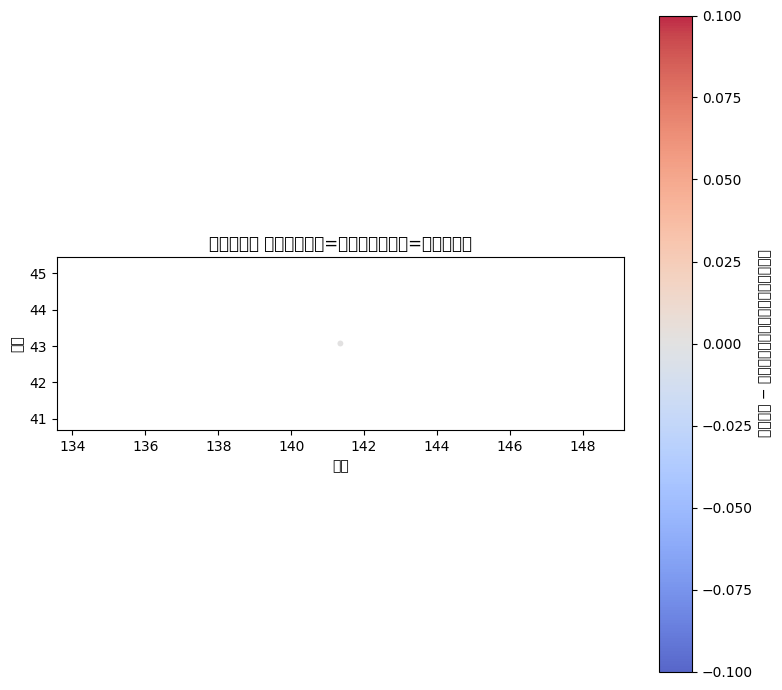

若年寄り上位メッシュ（diff）
            n_y  n_s  diff
mesh100mid                
6441428820  5.0  6.0   0.0

シニア寄り上位メッシュ（diff）
            n_y  n_s  diff
mesh100mid                
6441428820  5.0  6.0   0.0


In [21]:
# エリア（mesh100mid）: 若年シェア − 高齢シェア（棲み分けの目安）
MIN_MESH_START = 8  # まず厳しめに試し、メッシュが足りなければ段階的に緩める

n_y = mark[mark["segment"] == "young"].groupby("mesh100mid").size()
n_s = mark[mark["segment"] == "senior"].groupby("mesh100mid").size()
base = pd.DataFrame({"n_y": n_y, "n_s": n_s}).fillna(0)

merged = base.iloc[0:0].copy()
used_min = None
for min_m in range(MIN_MESH_START, 0, -1):
    m = base[(base["n_y"] >= min_m) & (base["n_s"] >= min_m)]
    if len(m) >= 1:
        merged = m
        used_min = min_m
        break

if len(merged) == 0:
    print("両層に同時に十分な件数があるメッシュがありません（データまたは層の定義を確認）。")
else:
    if used_min < MIN_MESH_START:
        print(f"注: MIN_MESH={MIN_MESH_START} だとメッシュが0件のため、{used_min} 件以上に緩めて表示します。")
    ty, ts = merged["n_y"].sum(), merged["n_s"].sum()
    merged = merged.copy()
    merged["p_y"] = merged["n_y"] / ty
    merged["p_s"] = merged["n_s"] / ts
    merged["diff"] = merged["p_y"] - merged["p_s"]

    centers = mark.groupby("mesh100mid").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
    plot_df = merged.join(centers, how="inner")

    if len(plot_df) == 0:
        print("メッシュ重心と結合後に表示できる点がありません。")
    else:
        v = plot_df["diff"].to_numpy()
        if len(v) == 1:
            lo, hi = float(v[0]), float(v[0])
        else:
            lo, hi = np.percentile(v, [2, 98])
        if lo >= hi:
            lo, hi = float(np.min(v)), float(np.max(v))

        fig, ax = plt.subplots(figsize=(8, 7))
        sc = ax.scatter(
            plot_df["lon"],
            plot_df["lat"],
            c=np.clip(v, lo, hi),
            cmap="coolwarm",
            s=18,
            alpha=0.85,
            edgecolors="none",
        )
        plt.colorbar(sc, ax=ax, label="若年割合 − 高齢割合（各層の全到着で正規化）")
        ax.set_xlabel("経度")
        ax.set_ylabel("緯度")
        ax.set_title("メッシュ別 層の偏り（青=シニア寄り、赤=若年寄り）")
        ax.set_aspect("equal", adjustable="box")
        plt.tight_layout()
        plt.show()

        print("若年寄り上位メッシュ（diff）")
        print(plot_df.sort_values("diff", ascending=False).head(10)[["n_y", "n_s", "diff"]])
        print("\nシニア寄り上位メッシュ（diff）")
        print(plot_df.sort_values("diff", ascending=True).head(10)[["n_y", "n_s", "diff"]])

In [22]:
# 深夜帯に限定した同様の比較（防犯・深夜需要の議論用。サンプルが少ないとメッシュが減る）
mark_n = mark[mark["hour"].isin([22, 23, 0, 1, 2, 3, 4])]
MIN_NIGHT = 3
if len(mark_n) >= 50:
    n_y = mark_n[mark_n["segment"] == "young"].groupby("mesh100mid").size()
    n_s = mark_n[mark_n["segment"] == "senior"].groupby("mesh100mid").size()
    merged_n = pd.DataFrame({"n_y": n_y, "n_s": n_s}).fillna(0)
    merged_n = merged_n[(merged_n["n_y"] >= MIN_NIGHT) & (merged_n["n_s"] >= MIN_NIGHT)]
    if len(merged_n) > 0:
        ty, ts = merged_n["n_y"].sum(), merged_n["n_s"].sum()
        merged_n["p_y"] = merged_n["n_y"] / ty
        merged_n["p_s"] = merged_n["n_s"] / ts
        merged_n["diff"] = merged_n["p_y"] - merged_n["p_s"]
        centers_n = mark_n.groupby("mesh100mid").agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
        plot_n = merged_n.join(centers_n, how="inner")
        if len(plot_n) == 0:
            print("深夜帯: メッシュ重心と結合後に表示できる点がありません")
        else:
            v = plot_n["diff"].to_numpy()
            if len(v) == 1:
                lo, hi = float(v[0]), float(v[0])
            else:
                lo, hi = np.percentile(v, [5, 95])
            if lo >= hi:
                lo, hi = float(np.min(v)), float(np.max(v))
            fig, ax = plt.subplots(figsize=(8, 7))
            sc = ax.scatter(
                plot_n["lon"],
                plot_n["lat"],
                c=np.clip(v, lo, hi),
                cmap="coolwarm",
                s=28,
                alpha=0.9,
                edgecolors="none",
            )
            plt.colorbar(sc, ax=ax, label="若年割合 − 高齢割合（深夜帯のみ）")
            ax.set_xlabel("経度")
            ax.set_ylabel("緯度")
            ax.set_title("深夜帯（22–23, 0–4時）到着のみ: メッシュ別の層の偏り")
            ax.set_aspect("equal", adjustable="box")
            plt.tight_layout()
            plt.show()
    else:
        print("深夜帯: 両層の最小件数を満たすメッシュがありません")
else:
    print("深夜帯の到着サンプルが少ないためスキップ（件数: %d）" % len(mark_n))

深夜帯: 両層の最小件数を満たすメッシュがありません


In [30]:
# 若年層（10代・20代）: 午前（0-11時）ヒートマップ
try:
    from IPython.display import display
    import folium
    from folium.plugins import HeatMap

    hours = list(range(0, 12))
    d = mark[(mark["segment"] == "young") & (mark["hour"].isin(hours))].copy()
    print(f"young_morning: {len(d):,} records")

    if len(d) == 0:
        print("  -> データなし")
    else:
        center_lat = float(mark["latitude"].median())
        center_lon = float(mark["longitude"].median())
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=10,
            tiles="OpenStreetMap",
            control_scale=True,
        )
        heat_data = d[["latitude", "longitude"]].values.tolist()
        HeatMap(heat_data, radius=12, blur=18, max_zoom=13).add_to(m)
        display(m)
except ImportError:
    print("インタラクティブ地図を使う場合: pip install folium")

young_morning: 261 records


In [31]:
# 若年層（10代・20代）: 午後（12-23時）ヒートマップ
try:
    from IPython.display import display
    import folium
    from folium.plugins import HeatMap

    hours = list(range(12, 24))
    d = mark[(mark["segment"] == "young") & (mark["hour"].isin(hours))].copy()
    print(f"young_afternoon: {len(d):,} records")

    if len(d) == 0:
        print("  -> データなし")
    else:
        center_lat = float(mark["latitude"].median())
        center_lon = float(mark["longitude"].median())
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=10,
            tiles="OpenStreetMap",
            control_scale=True,
        )
        heat_data = d[["latitude", "longitude"]].values.tolist()
        HeatMap(heat_data, radius=12, blur=18, max_zoom=13).add_to(m)
        display(m)
except ImportError:
    print("インタラクティブ地図を使う場合: pip install folium")

young_afternoon: 360 records


In [34]:
# 高齢層: 午前（0-11時）ヒートマップ
try:
    from IPython.display import display
    import folium
    from folium.plugins import HeatMap

    hours = list(range(0, 12))
    d = mark[(mark["segment"] == "senior") & (mark["hour"].isin(hours))].copy()
    print(f"senior_morning: {len(d):,} records")

    if len(d) == 0:
        print("  -> データなし")
    else:
        center_lat = float(mark["latitude"].median())
        center_lon = float(mark["longitude"].median())
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=10,
            tiles="OpenStreetMap",
            control_scale=True,
        )
        heat_data = d[["latitude", "longitude"]].values.tolist()
        HeatMap(heat_data, radius=12, blur=18, max_zoom=13).add_to(m)
        display(m)
except ImportError:
    print("インタラクティブ地図を使う場合: pip install folium")

senior_morning: 96 records


In [33]:
# 高齢層: 午後（12-23時）ヒートマップ
try:
    from IPython.display import display
    import folium
    from folium.plugins import HeatMap

    hours = list(range(12, 24))
    d = mark[(mark["segment"] == "senior") & (mark["hour"].isin(hours))].copy()
    print(f"senior_afternoon: {len(d):,} records")

    if len(d) == 0:
        print("  -> データなし")
    else:
        center_lat = float(mark["latitude"].median())
        center_lon = float(mark["longitude"].median())
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=10,
            tiles="OpenStreetMap",
            control_scale=True,
        )
        heat_data = d[["latitude", "longitude"]].values.tolist()
        HeatMap(heat_data, radius=12, blur=18, max_zoom=13).add_to(m)
        display(m)
except ImportError:
    print("インタラクティブ地図を使う場合: pip install folium")

senior_afternoon: 113 records
